In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 결과 파일이 있는 경로
out_dir = "/data1/project/yeonu/065_multi_rna/Deg_80/results_output"

In [2]:
# 설정값
p_cutoff = 0.05
fc_cutoff = 0.5

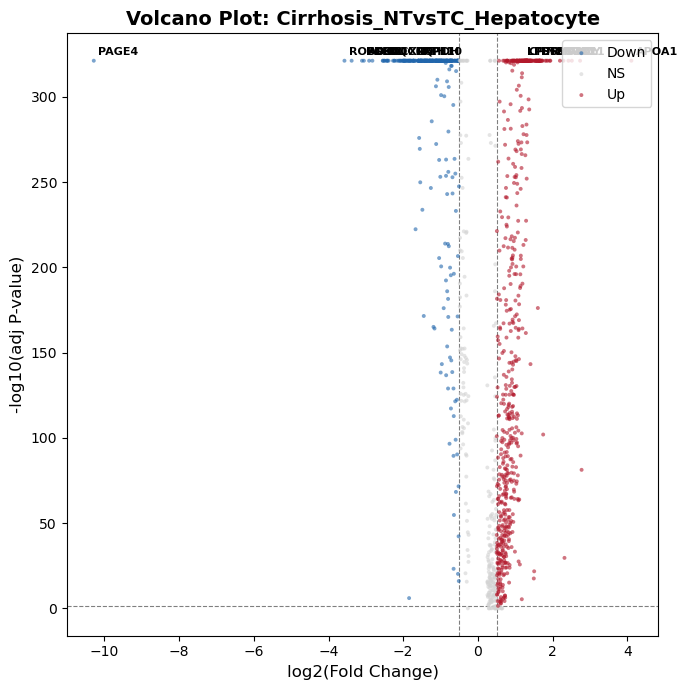

In [5]:
# 파일 로드
file_name = "MAST_DEGs_Cirrhosis_NTvsTC_Hepatocyte.csv"
df = pd.read_csv(os.path.join(out_dir, file_name))

# -log10(padj) 계산 및 0 처리
min_nonzero_p = df.loc[df["padj"] > 0, "padj"].min() if any(df["padj"] > 0) else 1e-300
df["padj_fixed"] = df["padj"].replace(0, min_nonzero_p * 0.1)
df["neg_log10_padj"] = -np.log10(df["padj_fixed"])

# Significance 분류
df["sig"] = "NS"
df.loc[(df["log2FC"] >= fc_cutoff) & (df["padj"] < p_cutoff), "sig"] = "Up"
df.loc[(df["log2FC"] <= -fc_cutoff) & (df["padj"] < p_cutoff), "sig"] = "Down"

colors = {"Down": "#2166AC", "NS": "lightgrey", "Up": "#B2182B"}

fig, ax = plt.subplots(figsize=(7, 7))

# 산점도 그리기
for sig, color in colors.items():
    sub = df[df["sig"] == sig]
    ax.scatter(sub["log2FC"], sub["neg_log10_padj"],
               c=color, s=8, alpha=0.6, label=sig, edgecolors='none', zorder=3)

# 가이드라인
ax.axhline(-np.log10(p_cutoff), linestyle="--", color="black", linewidth=0.8, alpha=0.5, zorder=1)
ax.axvline(fc_cutoff, linestyle="--", color="black", linewidth=0.8, alpha=0.5, zorder=1)
ax.axvline(-fc_cutoff, linestyle="--", color="black", linewidth=0.8, alpha=0.5, zorder=1)

# 텍스트 라벨링: Up/Down 각각 상위 10개
top_up = df[df["sig"] == "Up"].nsmallest(10, "padj")
top_down = df[df["sig"] == "Down"].nsmallest(10, "padj")
top_genes = pd.concat([top_up, top_down])

for _, row in top_genes.iterrows():
    ax.annotate(row["gene"],
                xy=(row["log2FC"], row["neg_log10_padj"]),
                xytext=(3, 3),
                textcoords="offset points",
                fontsize=8,
                fontweight='bold',
                ha="left",
                va="bottom")

# 스타일링
label = file_name.replace("MAST_DEGs_", "").replace(".csv", "")
ax.set_title(f"Volcano Plot: {label}", fontsize=14, fontweight='bold')
ax.set_xlabel("log2(Fold Change)", fontsize=12)
ax.set_ylabel("-log10(adj P-value)", fontsize=12)
ax.legend(loc="upper right", frameon=True)

# # 카운트 표시
# n_up = (df["sig"] == "Up").sum()
# n_down = (df["sig"] == "Down").sum()
# ax.text(0.05, 0.95, f"Up: {n_up}\nDown: {n_down}",
#         transform=ax.transAxes, fontsize=10, fontweight='bold',
#         verticalalignment="top", bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.tight_layout()
plt.show()

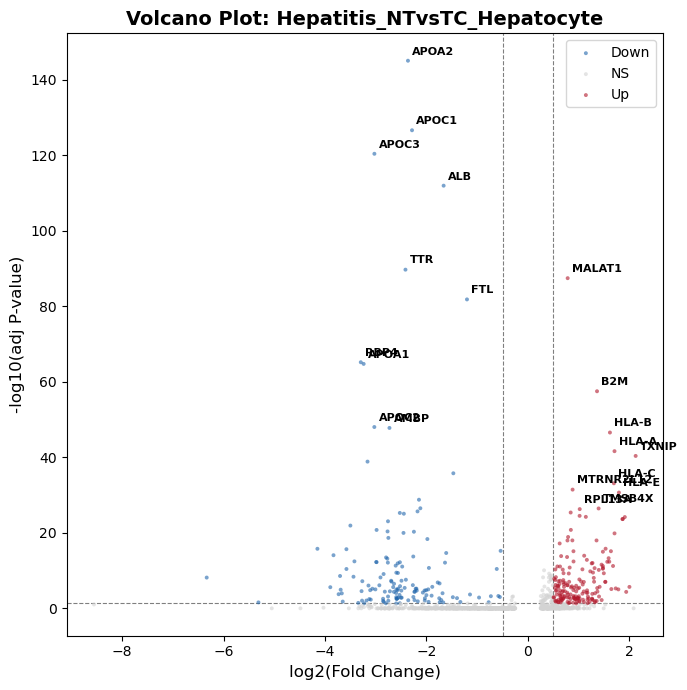

In [6]:
# 파일 로드
file_name = "MAST_DEGs_Hepatitis_NTvsTC_Hepatocyte.csv"
df = pd.read_csv(os.path.join(out_dir, file_name))

# -log10(padj) 계산 및 0 처리
min_nonzero_p = df.loc[df["padj"] > 0, "padj"].min() if any(df["padj"] > 0) else 1e-300
df["padj_fixed"] = df["padj"].replace(0, min_nonzero_p * 0.1)
df["neg_log10_padj"] = -np.log10(df["padj_fixed"])

# Significance 분류
df["sig"] = "NS"
df.loc[(df["log2FC"] >= fc_cutoff) & (df["padj"] < p_cutoff), "sig"] = "Up"
df.loc[(df["log2FC"] <= -fc_cutoff) & (df["padj"] < p_cutoff), "sig"] = "Down"

colors = {"Down": "#2166AC", "NS": "lightgrey", "Up": "#B2182B"}

fig, ax = plt.subplots(figsize=(7, 7))

# 산점도 그리기
for sig, color in colors.items():
    sub = df[df["sig"] == sig]
    ax.scatter(sub["log2FC"], sub["neg_log10_padj"],
               c=color, s=8, alpha=0.6, label=sig, edgecolors='none', zorder=3)

# 가이드라인
ax.axhline(-np.log10(p_cutoff), linestyle="--", color="black", linewidth=0.8, alpha=0.5, zorder=1)
ax.axvline(fc_cutoff, linestyle="--", color="black", linewidth=0.8, alpha=0.5, zorder=1)
ax.axvline(-fc_cutoff, linestyle="--", color="black", linewidth=0.8, alpha=0.5, zorder=1)

# 텍스트 라벨링: Up/Down 각각 상위 10개
top_up = df[df["sig"] == "Up"].nsmallest(10, "padj")
top_down = df[df["sig"] == "Down"].nsmallest(10, "padj")
top_genes = pd.concat([top_up, top_down])

for _, row in top_genes.iterrows():
    ax.annotate(row["gene"],
                xy=(row["log2FC"], row["neg_log10_padj"]),
                xytext=(3, 3),
                textcoords="offset points",
                fontsize=8,
                fontweight='bold',
                ha="left",
                va="bottom")

# 스타일링
label = file_name.replace("MAST_DEGs_", "").replace(".csv", "")
ax.set_title(f"Volcano Plot: {label}", fontsize=14, fontweight='bold')
ax.set_xlabel("log2(Fold Change)", fontsize=12)
ax.set_ylabel("-log10(adj P-value)", fontsize=12)
ax.legend(loc="upper right", frameon=True)

# # 카운트 표시
# n_up = (df["sig"] == "Up").sum()
# n_down = (df["sig"] == "Down").sum()
# ax.text(0.05, 0.95, f"Up: {n_up}\nDown: {n_down}",
#         transform=ax.transAxes, fontsize=10, fontweight='bold',
#         verticalalignment="top", bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.tight_layout()
plt.show()